<a href="https://colab.research.google.com/github/PaolinaCastany/Master_Thesis/blob/main/ThesisPart3_strategy2_within_genre.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Thesis — Part 3 (Strategy 2)

This notebook implements **Strategy 2**: evaluate **global vs genre-specific models within each genre** (same test subset).

It saves:
- CSV: `strategy2_within_genre_regression_comparison.csv`, `strategy2_within_genre_classification_comparison.csv`, `genre_feature_importance_long.csv`
- Figures: `13_within_genre_regression_improvement.png`, `14_within_genre_classification_auc_delta.png`, `15_feature_importance_heatmap.png`


In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
)

BASE_FOLDER = "/content/drive/MyDrive/Thesis_Music_Success"
PATHS = {
    "data": os.path.join(BASE_FOLDER, "data"),
    "plots": os.path.join(BASE_FOLDER, "plots"),
    "results": os.path.join(BASE_FOLDER, "results"),
    "models": os.path.join(BASE_FOLDER, "models"),
}
for p in PATHS.values():
    os.makedirs(p, exist_ok=True)

sns.set_style("whitegrid")

def save_data(df, filename):
    fp = os.path.join(PATHS["results"], filename)
    df.to_csv(fp, index=False)
    print("✅ Saved:", fp)

def save_plot(filename):
    fp = os.path.join(PATHS["plots"], filename)
    plt.tight_layout()
    plt.savefig(fp, dpi=300, bbox_inches="tight")
    print("✅ Saved plot:", fp)


Mounted at /content/drive


In [2]:
# Load datasets created in Part 1
df_train = pd.read_csv(os.path.join(PATHS["data"], "spotify_train.csv"))
df_test  = pd.read_csv(os.path.join(PATHS["data"], "spotify_test.csv"))

assert "genre" in df_train.columns and "genre" in df_test.columns, "Missing 'genre' column."
assert "popularity" in df_train.columns and "is_hit" in df_train.columns, "Missing targets."

# Features (keep consistent with Part 2 fixed)
audio_features = [
    "danceability","energy","loudness","speechiness","acousticness",
    "instrumentalness","liveness","valence","tempo"
]
audio_features = [c for c in audio_features if c in df_train.columns]
if "duration_mins" in df_train.columns:
    audio_features.append("duration_mins")

num_features = audio_features.copy()
if "year" in df_train.columns and "year" not in num_features:
    num_features.append("year")

cat_features = ["genre"]  # for global model only (OHE)
X_cols_global = num_features + cat_features

print("Numeric features:", num_features)
print("Global features:", X_cols_global)
print("Train/Test sizes:", len(df_train), len(df_test))


Numeric features: ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_mins', 'year']
Global features: ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_mins', 'year', 'genre']
Train/Test sizes: 133496 34798


In [3]:
# Targets
y_train_log = np.log1p(df_train["popularity"].values)
y_train_clf = df_train["is_hit"].values

def clip_pred_log(pred_log):
    return np.clip(pred_log, 0.0, np.log1p(100.0))


In [4]:
# Preprocess
preprocess_global = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
    ],
    remainder="drop"
)

preprocess_genre = ColumnTransformer(
    transformers=[("num", StandardScaler(), num_features)],
    remainder="drop"
)


In [5]:
# Train GLOBAL models (pooled)
global_reg = Pipeline(steps=[
    ("prep", preprocess_global),
    ("model", RandomForestRegressor(
        n_estimators=300,
        max_depth=20,
        min_samples_leaf=5,
        max_features="sqrt",
        bootstrap=True,
        max_samples=0.7,
        random_state=42,
        n_jobs=-1
    ))
])

global_clf = Pipeline(steps=[
    ("prep", preprocess_global),
    ("model", RandomForestClassifier(
        n_estimators=250,
        max_depth=14,
        min_samples_leaf=5,
        max_features="sqrt",
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1
    ))
])

t0 = time.time()
global_reg.fit(df_train[X_cols_global], y_train_log)
t_reg = time.time() - t0

t0 = time.time()
global_clf.fit(df_train[X_cols_global], y_train_clf)
t_clf = time.time() - t0

print(f"✅ Global models trained. reg_seconds={t_reg:.2f}, clf_seconds={t_clf:.2f}")


✅ Global models trained. reg_seconds=95.05, clf_seconds=76.96


In [6]:
# Strategy 2 — Within-genre comparison
genres = sorted(df_train["genre"].dropna().unique().tolist())

MIN_TRAIN = 2000
MIN_TEST  = 300

rows_reg = []
rows_clf = []
fi_rows = []

for g in tqdm(genres, desc="Within-genre eval (global vs specific)", unit="genre"):
    tr_g = df_train[df_train["genre"] == g].copy()
    te_g = df_test[df_test["genre"] == g].copy()

    if len(tr_g) < MIN_TRAIN or len(te_g) < MIN_TEST:
        continue

    # ---- Regression: global-on-genre ----
    pred_log_gl = clip_pred_log(global_reg.predict(te_g[X_cols_global]))
    pred_raw_gl = np.expm1(pred_log_gl)
    yte_raw = te_g["popularity"].values
    yte_log = np.log1p(yte_raw)

    mae_gl  = mean_absolute_error(yte_raw, pred_raw_gl)
    rmse_gl = mean_squared_error(yte_raw, pred_raw_gl) ** 0.5
    r2_gl   = r2_score(yte_log, pred_log_gl)

    # ---- Regression: genre-specific ----
    reg_g = Pipeline(steps=[
        ("prep", preprocess_genre),
        ("model", RandomForestRegressor(
            n_estimators=250,
            max_depth=20,
            min_samples_leaf=5,
            max_features="sqrt",
            bootstrap=True,
            max_samples=0.7,
            random_state=42,
            n_jobs=-1
        ))
    ])
    reg_g.fit(tr_g[num_features], np.log1p(tr_g["popularity"].values))
    pred_log_g = clip_pred_log(reg_g.predict(te_g[num_features]))
    pred_raw_g = np.expm1(pred_log_g)

    mae_g  = mean_absolute_error(yte_raw, pred_raw_g)
    rmse_g = mean_squared_error(yte_raw, pred_raw_g) ** 0.5
    r2_g   = r2_score(yte_log, pred_log_g)

    rows_reg.append({
        "genre": g,
        "n_test": len(te_g),
        "MAE_global_on_genre": mae_gl,
        "MAE_genre_specific": mae_g,
        "MAE_improvement_%": 100.0 * (mae_gl - mae_g) / mae_gl,
        "RMSE_global_on_genre": rmse_gl,
        "RMSE_genre_specific": rmse_g,
        "R2_log_global_on_genre": r2_gl,
        "R2_log_genre_specific": r2_g,
    })

    # Feature importance for heatmap (genre-specific reg)
    rf_model = reg_g.named_steps["model"]
    for feat, imp in zip(num_features, rf_model.feature_importances_):
        fi_rows.append({"genre": g, "feature": feat, "importance": imp})

    # ---- Classification: global-on-genre ----
    proba_gl = global_clf.predict_proba(te_g[X_cols_global])[:, 1]
    pred_gl  = (proba_gl >= 0.5).astype(int)
    yte_clf = te_g["is_hit"].values

    clf_metrics_gl = {
        "Accuracy_global_on_genre": accuracy_score(yte_clf, pred_gl),
        "Precision_global_on_genre": precision_score(yte_clf, pred_gl, zero_division=0),
        "Recall_global_on_genre": recall_score(yte_clf, pred_gl, zero_division=0),
        "F1_global_on_genre": f1_score(yte_clf, pred_gl, zero_division=0),
        "ROC_AUC_global_on_genre": roc_auc_score(yte_clf, proba_gl),
    }

    # ---- Classification: genre-specific ----
    clf_g = Pipeline(steps=[
        ("prep", preprocess_genre),
        ("model", RandomForestClassifier(
            n_estimators=220,
            max_depth=14,
            min_samples_leaf=5,
            max_features="sqrt",
            class_weight="balanced_subsample",
            random_state=42,
            n_jobs=-1
        ))
    ])
    clf_g.fit(tr_g[num_features], tr_g["is_hit"].values)
    proba_g = clf_g.predict_proba(te_g[num_features])[:, 1]
    pred_g  = (proba_g >= 0.5).astype(int)

    clf_metrics_g = {
        "Accuracy_genre_specific": accuracy_score(yte_clf, pred_g),
        "Precision_genre_specific": precision_score(yte_clf, pred_g, zero_division=0),
        "Recall_genre_specific": recall_score(yte_clf, pred_g, zero_division=0),
        "F1_genre_specific": f1_score(yte_clf, pred_g, zero_division=0),
        "ROC_AUC_genre_specific": roc_auc_score(yte_clf, proba_g),
    }

    rows_clf.append({
        "genre": g,
        "n_test": len(te_g),
        **clf_metrics_gl,
        **clf_metrics_g,
        "ROC_AUC_delta": clf_metrics_g["ROC_AUC_genre_specific"] - clf_metrics_gl["ROC_AUC_global_on_genre"],
        "F1_delta": clf_metrics_g["F1_genre_specific"] - clf_metrics_gl["F1_global_on_genre"],
    })

reg_within_df = pd.DataFrame(rows_reg).sort_values("MAE_improvement_%", ascending=False)
clf_within_df = pd.DataFrame(rows_clf).sort_values("ROC_AUC_delta", ascending=False)
fi_long = pd.DataFrame(fi_rows)

save_data(reg_within_df, "strategy2_within_genre_regression_comparison.csv")
save_data(clf_within_df, "strategy2_within_genre_classification_comparison.csv")
save_data(fi_long, "genre_feature_importance_long.csv")

display(reg_within_df)
display(clf_within_df)


Within-genre eval (global vs specific):   0%|          | 0/8 [00:00<?, ?genre/s]

✅ Saved: /content/drive/MyDrive/Thesis_Music_Success/results/strategy2_within_genre_regression_comparison.csv
✅ Saved: /content/drive/MyDrive/Thesis_Music_Success/results/strategy2_within_genre_classification_comparison.csv
✅ Saved: /content/drive/MyDrive/Thesis_Music_Success/results/genre_feature_importance_long.csv


,genre,n_test,MAE_global_on_genre,MAE_genre_specific,MAE_improvement_%,RMSE_global_on_genre,RMSE_genre_specific,R2_log_global_on_genre,R2_log_genre_specific
7,k-pop,4166,11.306174,10.918264,3.430961,14.748804,14.410255,0.054076,0.054407
6,indian,4391,15.411980,14.997906,2.686702,19.949221,19.476939,-0.610247,-0.509289
4,emo,4330,7.624698,7.485560,1.824832,10.228533,10.048170,0.025698,0.030105
2,ambient,4299,8.816079,8.659270,1.778664,11.713081,11.575675,0.003852,0.004810
3,black-metal,4584,6.648631,6.583070,0.986084,8.871097,8.767086,0.025042,0.029756
5,gospel,4473,9.986617,9.902792,0.839381,13.124293,13.040528,0.040038,0.040331
0,acoustic,4404,9.639182,9.568343,0.734906,12.570812,12.531272,-0.023922,-0.024058
1,alt-rock,4151,7.662973,7.659251,0.048583,11.208949,11.231562,-0.029287,-0.035819


,genre,n_test,Accuracy_global_on_genre,Precision_global_on_genre,Recall_global_on_genre,F1_global_on_genre,ROC_AUC_global_on_genre,Accuracy_genre_specific,Precision_genre_specific,Recall_genre_specific,F1_genre_specific,ROC_AUC_genre_specific,ROC_AUC_delta,F1_delta
0,acoustic,4404,0.887829,0.092593,0.281690,0.139373,0.695564,0.875795,0.077244,0.260563,0.119163,0.707767,0.012203,-0.020210
1,alt-rock,4151,0.285232,0.191662,0.897772,0.315887,0.559954,0.696218,0.223333,0.263434,0.241732,0.561370,0.001416,-0.074155
6,indian,4391,0.955591,0.000000,0.000000,0.000000,0.722223,0.955819,1.000000,0.005128,0.010204,0.719573,-0.002650,0.010204
4,emo,4330,0.400693,0.112482,0.803526,0.197340,0.631589,0.678522,0.128454,0.433249,0.198157,0.625589,-0.006000,0.000817
7,k-pop,4166,0.388142,0.338654,0.952844,0.499706,0.589710,0.517043,0.355802,0.624251,0.453261,0.569793,-0.019918,-0.046445
5,gospel,4473,0.941203,0.225806,0.143590,0.175549,0.827934,0.887995,0.149083,0.333333,0.206022,0.804665,-0.023269,0.030474
2,ambient,4299,0.888346,0.122667,0.233503,0.160839,0.756581,0.829728,0.108346,0.375635,0.168182,0.720382,-0.036199,0.007343
3,black-metal,4584,0.999127,0.000000,0.000000,0.000000,0.821779,0.999127,0.000000,0.000000,0.000000,0.478821,-0.342959,0.000000


✅ Saved plot: /content/drive/MyDrive/Thesis_Music_Success/plots/13_within_genre_regression_improvement.png


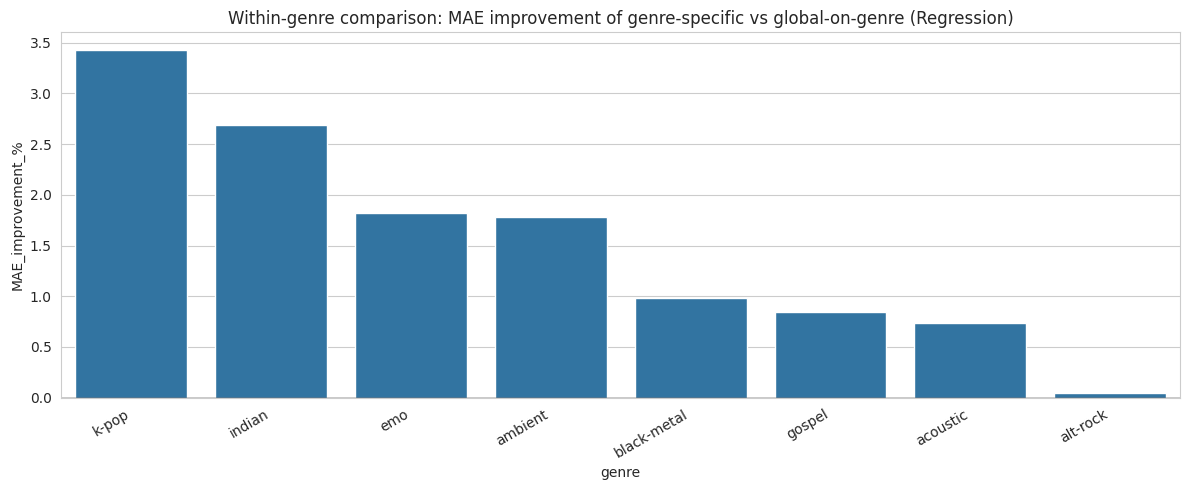

In [7]:
# Figure 13 — Within-genre regression improvement (% MAE)
plt.figure(figsize=(12,5))
sns.barplot(data=reg_within_df, x="genre", y="MAE_improvement_%")
plt.axhline(0, color="black", linewidth=1)
plt.xticks(rotation=30, ha="right")
plt.title("Within-genre comparison: MAE improvement of genre-specific vs global-on-genre (Regression)")
save_plot("13_within_genre_regression_improvement.png")
plt.show()


✅ Saved plot: /content/drive/MyDrive/Thesis_Music_Success/plots/14_within_genre_classification_auc_delta.png


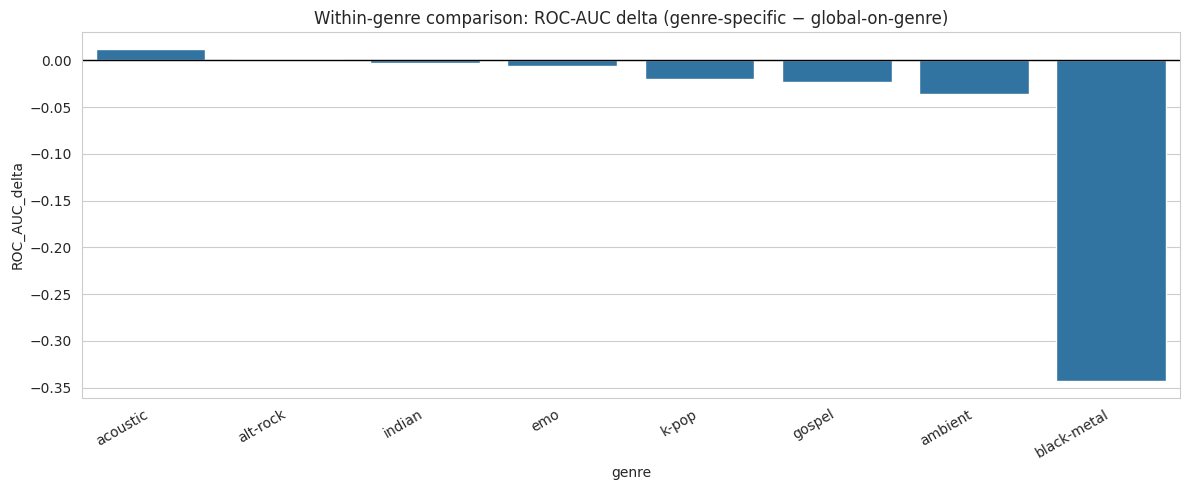

In [8]:
# Figure 14 — Within-genre classification improvement (Δ ROC-AUC)
plt.figure(figsize=(12,5))
sns.barplot(data=clf_within_df, x="genre", y="ROC_AUC_delta")
plt.axhline(0, color="black", linewidth=1)
plt.xticks(rotation=30, ha="right")
plt.title("Within-genre comparison: ROC-AUC delta (genre-specific − global-on-genre)")
save_plot("14_within_genre_classification_auc_delta.png")
plt.show()


✅ Saved plot: /content/drive/MyDrive/Thesis_Music_Success/plots/15_feature_importance_heatmap.png


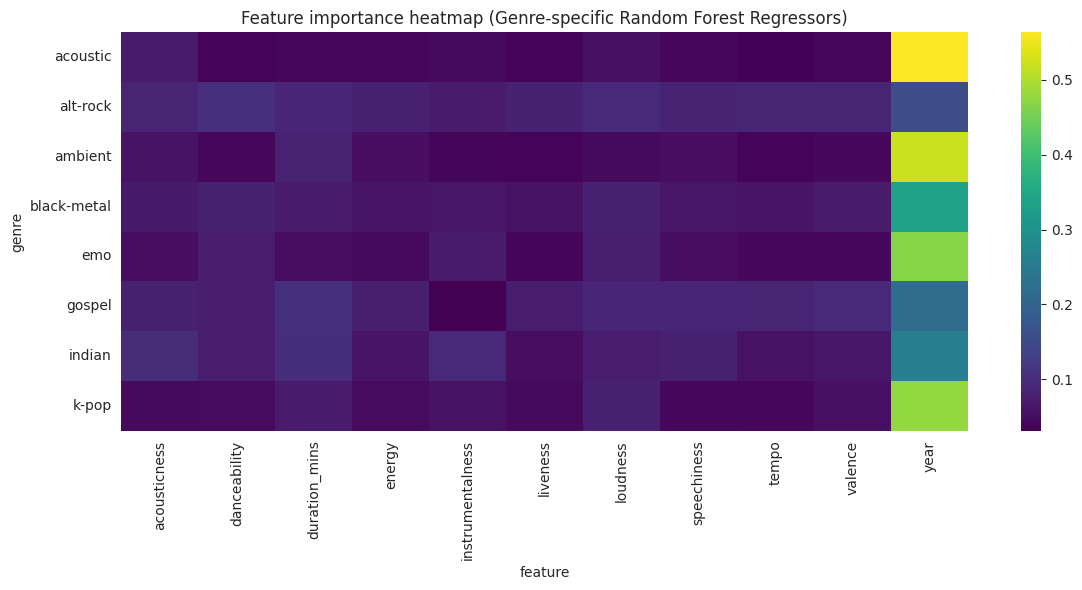

In [9]:
# Figure 15 — Feature importance heatmap (genre x feature)
pivot = fi_long.pivot_table(index="genre", columns="feature", values="importance", aggfunc="mean").fillna(0.0)

plt.figure(figsize=(12,6))
sns.heatmap(pivot, cmap="viridis")
plt.title("Feature importance heatmap (Genre-specific Random Forest Regressors)")
save_plot("15_feature_importance_heatmap.png")
plt.show()
